In [1]:
import os, pickle

from physics.simulation import mcfm, msq
from physics.analysis import zpair, zz4l
from physics.hstar import c6
from datasets import coefficient
from models import taylr

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import LogNorm
from matplotlib import ticker
import hist
import pandas as pd

import torch
from torch.utils.data import TensorDataset, DataLoader
from lightning import Trainer

In [ ]:
JOB_DIR = '../jobs/'
SAMPLE_DIR = '../../data'

TAYLR_JOB = 'ggZZ-2.5M'
TAYLR_CKPT = [[26,0.05],[87,0.16],[85,0.01],[50,0.03]]

VERSION_NO = [0, 0, 0, 0]

SAMPLE_FILE_ggZZ = 'ggZZ2e2m_sbi.csv'

TAYLR_PATH = os.path.join(JOB_DIR, 'taylr', TAYLR_JOB)
TAYLR_CKPT_PATHs = [os.path.join(TAYLR_PATH, f'coeff_{i+1}','checkpoints', f'checkpoint-taylr-epoch={TAYLR_CKPT[i][0]}-val_loss={TAYLR_CKPT[i][1]}.ckpt') for i in range(len(TAYLR_CKPT))]
SAMPLE_PATH_ggZZ = os.path.join(SAMPLE_DIR, SAMPLE_FILE_ggZZ)
LOG_DIRs = [os.path.join(TAYLR_PATH, f'coeff_{i+1}', 'lightning_logs', f'version_{VERSION_NO[i]}') for i in range(len(VERSION_NO))] 

In [3]:
FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

SAMPLE_SIZE = 1000000
BATCH_SIZE = 64
SEED = 42

In [4]:
xs_ggZZ = 1.5569109
luminosity = 3000

In [5]:
events_ggZZ = mcfm.from_csv(cross_section=xs_ggZZ, file_path=SAMPLE_PATH_ggZZ, n_rows=SAMPLE_SIZE*1.2)
        
z_cand = zpair.ZPairCandidate(algorithm='leastsquare')
z_masses = zpair.ZPairMassWindow(z1=(70,115), z2=(70,115))

fourlepton = zz4l.FourLeptonSystem()
lepton_momenta = zz4l.LeptonMomenta()

events_ggZZ_processed = events_ggZZ.calculate(z_cand).filter(z_masses).calculate(fourlepton).calculate(lepton_momenta)

sigma_ggZZ = events_ggZZ_processed.weights.sum()

events_ggZZ_processed = events_ggZZ_processed[:SAMPLE_SIZE]
events_ggZZ_processed.weights *= sigma_ggZZ/events_ggZZ_processed.weights.sum()

6.415952601856002


In [6]:
c6_mod = c6.Modifier(baseline=msq.Component.SBI, events=events_ggZZ_processed, c6_values=[-5,-1,0,1,5])
coefficients_true = c6_mod.coefficients
       
X = events_ggZZ_processed.kinematics[FEATURES].to_numpy()

dls = []

for i, path in enumerate([os.path.join(TAYLR_PATH, f'coeff_{i+1}', 'scaler_X.pkl') for i in range(len(TAYLR_CKPT))]):
    with open(path, 'rb') as f:
        scaler_X = pickle.load(f)
        X_i = torch.tensor(scaler_X.transform(X), dtype=torch.float32)
        ds_i = TensorDataset(X_i)
        dls.append(DataLoader(ds_i, batch_size=BATCH_SIZE, num_workers=15))

In [7]:
models = [taylr.TAYLR.load_from_checkpoint(TAYLR_CKPT_PATHs[i]) for i in range(len(TAYLR_CKPT))]

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:628: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/torch/cuda/__init__.py:758: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() if nvml_count < 0 else nvml_count


In [8]:
trainer = Trainer(accelerator='cpu')

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [9]:
coefficients_pred = [pickle.load(open(os.path.join(TAYLR_PATH, f'coeff_{i+1}', 'scaler_y.pkl'),'rb')).inverse_transform(torch.concatenate(trainer.predict(models[i], dls[i])).numpy()[:,np.newaxis]).flatten() for i in range(len(models))]

Predicting DataLoader 0: 100%|██████████| 15625/15625 [05:20<00:00, 48.82it/s]


In [10]:
def gen_plot(coeff_index, axes, colors, labels, bounds, bins):
    h_pred = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h_pred.fill(coefficients_pred[coeff_index], weight=events_ggZZ_processed.weights*luminosity)

    h_true = hist.Hist(hist.axis.Regular(bins, *bounds), storage=hist.storage.Weight())
    h_true.fill(coefficients_true[:,coeff_index+1], weight=events_ggZZ_processed.weights*luminosity)

    h_true.plot(ax=axes[0], color=colors[1], label=labels[1], linestyle='--', alpha=0.6)
    h_pred.plot(ax=axes[0], color=colors[0], label=labels[0], alpha=0.8)

    axes[0].tick_params(labelsize=12)
    axes[0].set_xlim(*bounds)
    axes[0].set_yscale('log')
    axes[0].set_ylabel('number of events', fontsize=12)
    axes[0].legend(frameon=False, fontsize=12)
    axes[0].set_xticklabels([])
    axes[0].set_xlabel('')

    axes[1].errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), drawstyle='steps-mid', color=colors[1], linestyle='--', alpha=0.6)
    axes[1].errorbar(h_pred.axes[0].centers, h_pred.values()/h_true.values(), yerr=np.sqrt((np.sqrt(h_pred.variances())/h_true.values())**2 + (-h_true.variances()*h_pred.values()/h_true.values()**2)**2), drawstyle='steps-mid', color=colors[0], alpha=0.8)

    axes[1].set_xlabel(f'$a_{coeff_index+1}$', fontsize=12)


In [11]:
BINS = 40

fig, axes = plt.subplots(4,2, gridspec_kw={'height_ratios': [4,1,4,1]}, figsize=(7,8), layout='constrained')

colors = ['royalblue', 'red']
labels = ['prediction', 'truth']

gen_plot(0, axes[:2,0], colors, labels, [-1.2e-2,6e-3], BINS)
gen_plot(1, axes[:2,1], colors, labels, [-1.2e-3,1.3e-3], BINS)
gen_plot(2, axes[2:,0], colors, labels, [-3.6e-5,1e-6], BINS)
gen_plot(3, axes[2:,1], colors, labels, [-3e-7,4.3e-6], BINS)

axes[0,1].set_xticks([-0.001,0.0,0.001])

plt.show()

/tmp/ipykernel_3820/1705634686.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), drawstyle='steps-mid', color=colors[1], linestyle='--', alpha=0.6)
/tmp/ipykernel_3820/1705634686.py:20: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_pred.axes[0].centers, h_pred.values()/h_true.values(), yerr=np.sqrt((np.sqrt(h_pred.variances())/h_true.values())**2 + (-h_true.variances()*h_pred.values()/h_true.values()**2)**2), drawstyle='steps-mid', color=colors[0], alpha=0.8)
/tmp/ipykernel_3820/1705634686.py:19: RuntimeWarning: invalid value encountered in divide
  axes[1].errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), drawstyle='steps-mid', color=colors[1], linestyle='--', alpha=0.6)
/tmp/ipykernel_3820/1705634686.py:20: RuntimeWarning: invalid value encountered in divide
 

In [12]:
def gen_calibration_plot(coeff_index, axes, colors, labels, bounds, bins):
    step_size = (bounds[1]-bounds[0])/bins

    p = coefficients_pred[coeff_index]
    t = coefficients_true[:, coeff_index+1]
    
    targets_binned = [t[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

    targets_mean = [np.average(targets_binned[i]) for i in range(bins)]
    targets_dev = [np.sqrt(np.average((targets_binned[i]-targets_mean[i])**2)) for i in range(bins)]

    centers = [bounds[0]+(i+1/2)*step_size for i in range(bins)]

    formatter_1 = ticker.ScalarFormatter(useMathText=True)
    formatter_1.set_scientific(True)
    formatter_1.set_powerlimits((-2,2))

    formatter_2 = ticker.ScalarFormatter(useMathText=True)
    formatter_2.set_scientific(True)
    formatter_2.set_powerlimits((-2,2))

    axes[0].set_xticklabels([])

    axes[0].yaxis.set_major_formatter(formatter_1)
    axes[1].yaxis.set_major_formatter(formatter_2)
    axes[1].xaxis.set_major_formatter(formatter_2)

    #axes[0].set_ticklabel_format(axis='both', style='sci', scilimits=(4,4))

    axes[0].errorbar(centers, centers, color='black', linestyle='--', label='targets')
    axes[0].errorbar(centers, targets_mean, yerr=targets_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

    axes[0].set_xlim(*bounds)
    axes[0].set_ylim(*bounds)
    axes[0].set_ylabel(f'truth  $a_{coeff_index+1}$')

    axes[0].legend(frameon=False)

    axes[1].errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', label='targets')
    axes[1].errorbar(centers, np.array(targets_mean)-np.array(centers), yerr=targets_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

    axes[1].set_xlim(*bounds)
    axes[1].set_xlabel(f'predicted $a_{coeff_index+1}$')
    axes[1].set_ylabel('Residual')


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/iwsatlas1/griesemx/ggZZ_work/venv_

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/lib/function_base.py:518: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


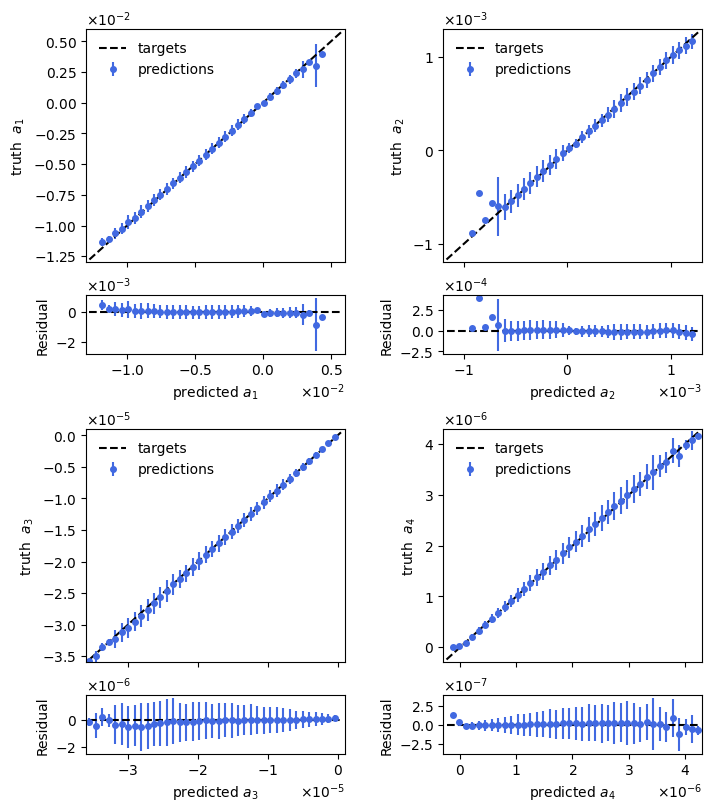

In [13]:
BINS = 40

fig, axes = plt.subplots(4,2, gridspec_kw={'height_ratios': [4,1,4,1], 'wspace': 0.1}, figsize=(7,8), layout='constrained')

colors = ['royalblue', 'red']
labels = ['prediction', 'truth']

gen_calibration_plot(0, axes[:2,0], colors, labels, [-1.3e-2,6e-3], BINS)
gen_calibration_plot(1, axes[:2,1], colors, labels, [-1.2e-3,1.3e-3], BINS)
gen_calibration_plot(2, axes[2:,0], colors, labels, [-3.6e-5,1e-6], BINS)
gen_calibration_plot(3, axes[2:,1], colors, labels, [-3e-7,4.3e-6], BINS)

axes[0,1].set_xticks([-0.001,0.0,0.001])
axes[0,1].set_yticks([-0.001,0.0,0.001])
axes[1,1].set_xticks([-0.001,0.0,0.001])

plt.show()

In [17]:
c6_val = 10

f_pred = np.apply_along_axis(lambda x: np.polyval(x, c6_val), 1, np.concatenate([np.ones((coefficients_true.shape[0],1)), np.array(coefficients_pred).T], axis=1)[:,::-1])

In [18]:
bins = 40
bounds = [180,1050]

h_true = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_true.fill(events_ggZZ_processed.kinematics[['4l_mass']].to_numpy().flatten(), weight=c6_mod.modify(c6_val)[1])

h_ggZZ = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_ggZZ.fill(events_ggZZ_processed.kinematics[['4l_mass']].to_numpy().flatten(), weight=events_ggZZ_processed.probabilities)

h_reweight = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_reweight.fill(events_ggZZ_processed.kinematics[['4l_mass']].to_numpy().flatten(), weight=(events_ggZZ_processed.weights*f_pred)/np.sum(events_ggZZ_processed.weights*f_pred))

fig, (ax1, ax2, ax3) = plt.subplots(3,1,gridspec_kw={'height_ratios': [4, 1, 1]},figsize=(7,9), layout='constrained')


h_ggZZ.plot(ax=ax1,color='black', linestyle='--', label='ggZZ($c6=0$)')
h_true.plot(ax=ax1,color='red', label=f'ggZZ($c_6={c6_val}$)', alpha=0.6)
h_reweight.plot(ax=ax1,color='royalblue', label=f'ggZZ($c_6=0$) $\\rightarrow$ ggZZ($c_6={c6_val}$) (estimated)', alpha=0.8)

ax1.tick_params(labelsize=12)
ax1.set_xlabel('')
ax1.set_ylabel('probability', fontsize=12)
ax1.set_xlim(180,1000)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=12)
ax1.set_xticklabels([])
ax1.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax2.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_reweight.values()/h_ggZZ.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')
ax2.errorbar(h_true.axes[0].centers, h_true.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_true.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_true.values()/h_ggZZ.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)

ax2.set_xticklabels([])
ax2.tick_params(labelsize=12)
ax2.set_ylabel('$p_{gg}(x|c_6)/p_{gg}(x|0)$', fontsize=12)
ax2.set_xlim(180,1000)
ax2.set_ylim(0.95,1.05)
ax2.set_xscale('log')
ax2.set_xticklabels([])
ax2.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax3.errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
ax3.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_true.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_true.values())**2 + (-np.sqrt(h_true.variances())*h_reweight.values()/h_true.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')

ax3.tick_params(labelsize=12)

ax3.set_xlabel('$m_{4\ell}$', fontsize=12)
ax3.set_ylabel('ratio', fontsize=12)
ax3.set_xlim(180,1000)
ax3.set_ylim(0.95,1.05)
ax3.set_xscale('log')

plt.tight_layout()

plt.show()

/tmp/ipykernel_3820/1008237864.py:31: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_reweight.values()/h_ggZZ.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')
/tmp/ipykernel_3820/1008237864.py:32: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(h_true.axes[0].centers, h_true.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_true.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_true.values()/h_ggZZ.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
/tmp/ipykernel_3820/1008237864.py:43: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), color='royalblue', drawstyle='steps-mid', la

In [16]:
metrics = pd.read_csv(os.path.join(OUTPUT_DIR, LIGHTNING_DIR, 'metrics.csv'))

epochs = np.unique(metrics['epoch'].to_numpy())
train_loss = metrics['train_loss'].dropna().to_numpy()
val_loss = metrics['val_loss'].dropna().to_numpy()

plt.plot(epochs+1, train_loss, color='royalblue', label='training')
plt.plot(epochs+1, val_loss, color='red', label='validation')

plt.xlabel('epochs')
plt.ylabel('loss')
#plt.xscale('log')
plt.yscale('log')
#plt.ylim(0.055355,0.05538)
plt.legend(frameon=False)
plt.show()

NameError: name 'OUTPUT_DIR' is not defined